# 1. Hypothesis Testing & Statistical Analysis

## Objective

Evaluate whether changing the first progression gate from **Level 30** to **Level 40** has a statistically significant impact on player retention.

Unlike the previous notebook, which focused on understanding and validating the data, this notebook applies statistical inference to determine whether the observed differences between the control and treatment groups are likely due to the experimental change or random variation.

# 2. Business Question

## Problem Statement

Cookie Cats currently places the first progression gate at **Level 30**. The experiment tests whether delaying this gate to **Level 40** changes player retention.

The objective is to determine whether the new game design improves or harms player retention and whether the observed difference is large enough to justify deploying the change.

### Experiment Groups

- **Control Group:** `gate_30`
- **Treatment Group:** `gate_40`

### Primary Metrics

- One-Day Retention (`retention_1`)
- Seven-Day Retention (`retention_7`)

# 3. Statistical Framework

## Objective

Define the statistical hypotheses and significance level that will be used to evaluate the experiment.

### Significance Level

A significance level of **5% (α = 0.05)** is used throughout this analysis.

If the p-value is less than 0.05, the observed difference is considered statistically significant, indicating that it is unlikely to have occurred due to random chance alone.

### 3.1 One-Day Retention

#### Null Hypothesis (H₀)

The one-day retention rate is the same for both experiment groups.

\[
H_0 : p_{30} = p_{40}
\]

#### Alternative Hypothesis (H₁)

The one-day retention rate differs between the two experiment groups.

\[
H_1 : p_{30} \neq p_{40}
\]

### 3.2 Seven-Day Retention

#### Null Hypothesis (H₀)

The seven-day retention rate is the same for both experiment groups.

\[
H_0 : p_{30} = p_{40}
\]

#### Alternative Hypothesis (H₁)

The seven-day retention rate differs between the two experiment groups.

\[
H_1 : p_{30} \neq p_{40}
\]

# 4. One-Day Retention Analysis

## Objective

Calculate and compare the one-day retention rates for the control (`gate_30`) and treatment (`gate_40`) groups. Before conducting statistical hypothesis testing, this section examines the observed retention difference to understand its potential business impact.

### 4.1 Retention Rate

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import chisquare

In [3]:
df = pd.read_csv("../data/cleaned/cookie_cats_cleaned.csv")

In [5]:
retention_1 = (
    df.groupby("version")["retention_1"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "Total Players",
          "sum": "Retained Players",
          "mean": "Retention Rate"
      })
)

retention_1["Retention Rate"] *= 100

retention_1.round(2)

,Total Players,Retained Players,Retention Rate
version,,,
gate_30,44700,20034,44.82
gate_40,45489,20119,44.23


### 4.2 Retention Difference

Calculate the absolute difference in one-day retention between the control and treatment groups to understand the observed effect before testing its statistical significance.

In [6]:
gate30 = retention_1.loc["gate_30", "Retention Rate"]
gate40 = retention_1.loc["gate_40", "Retention Rate"]

difference = gate30 - gate40

print(f"Gate 30 Retention : {gate30:.2f}%")
print(f"Gate 40 Retention : {gate40:.2f}%")
print(f"Absolute Difference : {difference:.2f} percentage points")

Gate 30 Retention : 44.82%
Gate 40 Retention : 44.23%
Absolute Difference : 0.59 percentage points


#### 4.3 Visualize the retention rates

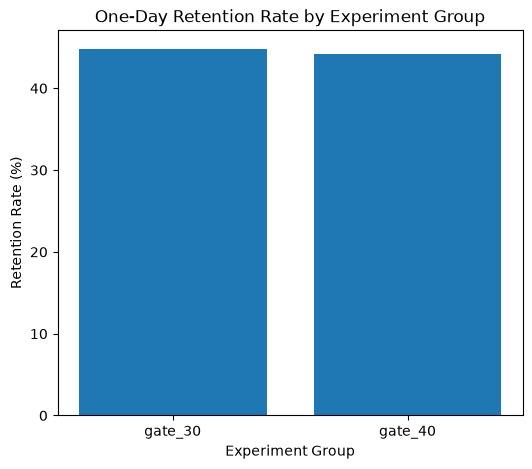

In [7]:
plt.figure(figsize=(6,5))

plt.bar(
    retention_1.index,
    retention_1["Retention Rate"]
)

plt.title("One-Day Retention Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Retention Rate (%)")

plt.show()

### 4.4 Interpretation

#### Key Insights

- The control group (`gate_30`) achieved a **one-day retention rate of 44.82%**.
- The treatment group (`gate_40`) achieved a **one-day retention rate of 44.23%**.
- The observed difference is **0.59 percentage points** in favor of `gate_30`.
- At face value, players exposed to the Level 30 gate appear slightly more likely to return the next day.
- However, the observed difference alone is insufficient to conclude that the experimental change caused the difference.

#### Business Perspective

Although the retention difference appears small, even fractional improvements in player retention can translate into a substantial increase in returning users when applied across millions of players. The next step is to determine whether this observed difference reflects a genuine effect of the gate placement or is simply due to random variation.

### 4.5 Relative Difference

#### Objective

Calculate the relative percentage change in one-day retention between the treatment and control groups. This provides a business-oriented view of the experiment's impact.

In [8]:
relative_change = ((gate40 - gate30) / gate30) * 100

print(f"Relative Change: {relative_change:.2f}%")

Relative Change: -1.32%


#### Key Insight

- The treatment group (`gate_40`) experienced approximately a **1.3% relative decrease** in one-day retention compared to the control group (`gate_30`).
- This indicates that delaying the progression gate was associated with a slight reduction in the proportion of players returning the next day.
- However, the practical importance of this decrease cannot be assessed without determining whether it is statistically significant.

# 5. One-Day Retention: Two-Proportion Z-Test

## Objective

Determine whether the observed difference in one-day retention between the control (`gate_30`) and treatment (`gate_40`) groups is statistically significant.

The Two-Proportion Z-Test is appropriate because:

- The outcome (retained or not retained) is binary.
- The two experiment groups are independent.
- Both groups contain a sufficiently large number of observations.
- We are comparing the proportions of two populations.

### 5.1 Prepare the Data

Extract the number of retained players and total players for each experiment group. These values serve as the inputs to the statistical test.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

successes = [
    retention_1.loc["gate_30", "Retained Players"],
    retention_1.loc["gate_40", "Retained Players"]
]

totals = [
    retention_1.loc["gate_30", "Total Players"],
    retention_1.loc["gate_40", "Total Players"]
]

print("Retained Players :", successes)
print("Total Players    :", totals)

Retained Players : [np.int64(20034), np.int64(20119)]
Total Players    : [np.int64(44700), np.int64(45489)]


### 5.2 Perform the Statistical Test

Perform a Two-Proportion Z-Test to compare one-day retention rates between the control and treatment groups.

The test evaluates whether the observed difference in retention is likely due to the experimental change or random sampling variation.


In [10]:
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=totals,
    alternative="two-sided"
)

print(f"Z-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

Z-Statistic : 1.7841
P-Value     : 0.074410


### 5.3 Statistical Decision

Compare the p-value with the significance level (α = 0.05) to determine whether the null hypothesis should be rejected.

In [11]:
alpha = 0.05

if p_value < alpha:
    print("Decision : Reject the Null Hypothesis")
else:
    print("Decision : Fail to Reject the Null Hypothesis")

Decision : Fail to Reject the Null Hypothesis


### 5.4 Interpretation

#### Statistical Results

- **Z-Statistic:** 1.7841
- **P-Value:** 0.0744
- Since the p-value is greater than the significance level (α = 0.05), we fail to reject the null hypothesis.

#### Key Insights

- The observed difference in one-day retention (**44.82% vs. 44.23%**) is **not statistically significant** at the 5% significance level.
- The experiment does not provide sufficient statistical evidence that moving the progression gate from Level 30 to Level 40 changed one-day player retention.
- Although the control group showed a slightly higher retention rate, the observed difference could reasonably be explained by random sampling variation.

#### Business Perspective

Based on one-day retention alone, there is insufficient evidence to recommend changing the progression gate from Level 30 to Level 40. However, the final product decision should also consider seven-day retention, effect size, confidence intervals, and other supporting analyses before drawing a conclusion.

### Assumptions

-  Binary outcome (retained / not retained)
-  Independent experiment groups
-  Large sample sizes in both groups
-  Normal approximation conditions satisfied

# 6. Confidence Interval

## Objective

Estimate the 95% confidence interval for the difference in one-day retention between the control and treatment groups.

While the hypothesis test indicates whether a statistically significant difference exists, the confidence interval provides a range of plausible values for the true retention difference and helps quantify the uncertainty associated with the estimate.

### 6.1 Compute the Confidence Interval

Calculate the 95% confidence interval for the difference in one-day retention rates between the two experiment groups.

In [12]:
from statsmodels.stats.proportion import confint_proportions_2indep

count1 = retention_1.loc["gate_30", "Retained Players"]
nobs1 = retention_1.loc["gate_30", "Total Players"]

count2 = retention_1.loc["gate_40", "Retained Players"]
nobs2 = retention_1.loc["gate_40", "Total Players"]

lower, upper = confint_proportions_2indep(
    count1,
    nobs1,
    count2,
    nobs2,
    compare="diff",
    method="wald"
)

print(f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})")
print(f"({lower*100:.2f}%, {upper*100:.2f}%)")

95% Confidence Interval: (-0.0006, 0.0124)
(-0.06%, 1.24%)


### 6.2 Interpretation

#### Statistical Results

- **95% Confidence Interval:** **(-0.06%, 1.24%)**

#### Key Insights

- The estimated difference in one-day retention ranges from **-0.06 percentage points** to **1.24 percentage points**.
- Since the confidence interval includes **0**, the true retention difference could be zero.
- This indicates that the observed difference is **not statistically significant** at the 95% confidence level.
- Although the control group showed a slightly higher retention rate, the true effect may be negligible or even nonexistent.

#### Business Perspective

The confidence interval suggests that delaying the progression gate from Level 30 to Level 40 is unlikely to produce a meaningful improvement in one-day retention. Any observed difference is small and falls within the range of normal sampling variation.

# 7. Effect Size (Cohen's h)

## Objective

Statistical significance does not necessarily imply practical significance. Therefore, alongside hypothesis testing, we calculate **Cohen's h** to measure the magnitude of the difference in one-day retention between the control and treatment groups.

Unlike the p-value, Cohen's h is independent of sample size and helps determine whether the observed difference is meaningful from a practical perspective.

### 7.1 Compute Effect Size

Calculate Cohen's h using the observed one-day retention rates of the two experiment groups.

In [13]:
from statsmodels.stats.proportion import proportion_effectsize

p1 = retention_1.loc["gate_30", "Retention Rate"] / 100
p2 = retention_1.loc["gate_40", "Retention Rate"] / 100

cohens_h = proportion_effectsize(p1, p2)

print(f"Cohen's h: {cohens_h:.4f}")

Cohen's h: 0.0119


### 7.2 Interpretation Scale

According to Cohen (1988):

| Absolute Effect Size | Interpretation |
|---------------------:|----------------|
| < 0.20 | Negligible |
| 0.20 – 0.50 | Small |
| 0.50 – 0.80 | Medium |
| > 0.80 | Large |

In [14]:
effect = abs(cohens_h)

if effect < 0.20:
    interpretation = "Negligible"
elif effect < 0.50:
    interpretation = "Small"
elif effect < 0.80:
    interpretation = "Medium"
else:
    interpretation = "Large"

print(f"Effect Size: {effect:.4f}")
print(f"Interpretation: {interpretation}")

Effect Size: 0.0119
Interpretation: Negligible


### 7.3 Interpretation

#### Statistical Results

- **Cohen's h:** **0.0119**
- **Effect Size:** **Negligible**

#### Key Insights

- The observed difference in one-day retention corresponds to a **negligible practical effect**.
- Although the control group achieved a slightly higher retention rate, the magnitude of the difference is extremely small.
- The effect size is well below Cohen's threshold of **0.20** for a small effect, indicating that the treatment had little practical influence on player behavior.

#### Business Perspective

Even if the observed retention difference had been statistically significant, its practical impact would remain minimal. From a product perspective, such a small effect alone is unlikely to justify changing the progression gate.

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Retention Difference",
        "Relative Change",
        "P-Value",
        "95% Confidence Interval",
        "Cohen's h",
        "Practical Effect"
    ],
    "Result": [
        f"{difference:.2f} percentage points",
        f"{relative_change:.2f}%",
        f"{p_value:.4f}",
        f"({lower*100:.2f}%, {upper*100:.2f}%)",
        f"{effect:.4f}",
        interpretation
    ]
})

summary

,Metric,Result
0,Retention Difference,0.59 percentage points
1,Relative Change,-1.32%
2,P-Value,0.0744
3,95% Confidence Interval,"(-0.06%, 1.24%)"
4,Cohen's h,0.0119
5,Practical Effect,Negligible


# 8. Seven-Day Retention Analysis

## Objective

Evaluate whether delaying the progression gate from **Level 30** to **Level 40** significantly affects seven-day player retention.

Seven-day retention is often considered a stronger indicator of long-term player engagement than one-day retention. Therefore, it provides additional evidence for determining whether the experimental change should be adopted.

### 8.1 Calculate Retention Rates

Compute the seven-day retention rates for both experiment groups before performing statistical inference.

In [16]:
retention_7 = (
    df.groupby("version")["retention_7"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "Total Players",
          "sum": "Retained Players",
          "mean": "Retention Rate"
      })
)

retention_7["Retention Rate"] *= 100

retention_7.round(2)

,Total Players,Retained Players,Retention Rate
version,,,
gate_30,44700,8502,19.02
gate_40,45489,8279,18.20


### 8.2 Compare Retention Rates

Calculate both the absolute and relative differences in seven-day retention between the control and treatment groups.

In [17]:
gate30_7 = retention_7.loc["gate_30", "Retention Rate"]
gate40_7 = retention_7.loc["gate_40", "Retention Rate"]

difference_7 = gate30_7 - gate40_7

relative_change_7 = ((gate40_7 - gate30_7) / gate30_7) * 100

print(f"Gate 30 Retention : {gate30_7:.2f}%")
print(f"Gate 40 Retention : {gate40_7:.2f}%")

print(f"\nAbsolute Difference : {difference_7:.2f} percentage points")
print(f"Relative Change     : {relative_change_7:.2f}%")

Gate 30 Retention : 19.02%
Gate 40 Retention : 18.20%

Absolute Difference : 0.82 percentage points
Relative Change     : -4.31%


### 8.3 Visualize Seven-Day Retention

Visualize the seven-day retention rates for both experiment groups to provide a quick comparison before performing statistical inference.

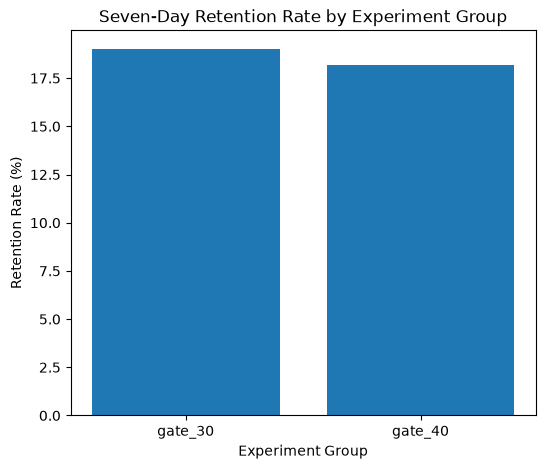

In [18]:
plt.figure(figsize=(6,5))

plt.bar(
    retention_7.index,
    retention_7["Retention Rate"]
)

plt.title("Seven-Day Retention Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Retention Rate (%)")

plt.show()

### 8.4 Interpretation

#### Statistical Results

- **Gate 30 Retention:** **19.02%**
- **Gate 40 Retention:** **18.20%**
- **Absolute Difference:** **0.82 percentage points**
- **Relative Change:** **-4.31%**

#### Key Insights

- Players assigned to **gate_30** exhibited a higher seven-day retention rate than those assigned to **gate_40**.
- The absolute difference of **0.82 percentage points** is larger than the difference observed in one-day retention.
- The treatment group experienced a **4.31% relative decrease** in seven-day retention compared to the control group.

#### Business Perspective

Unlike one-day retention, the difference between the two groups becomes more pronounced after seven days. Statistical testing is required to determine whether this observed difference reflects a genuine treatment effect or random variation.

# 9. Seven-Day Two-Proportion Z-Test

## Objective

Determine whether the observed difference in seven-day retention between the control (`gate_30`) and treatment (`gate_40`) groups is statistically significant.

### 9.1 Prepare the Data

Extract the number of retained players and the total number of players in each experiment group for the seven-day retention analysis.

In [20]:
successes_7 = [
    retention_7.loc["gate_30", "Retained Players"],
    retention_7.loc["gate_40", "Retained Players"]
]

totals_7 = [
    retention_7.loc["gate_30", "Total Players"],
    retention_7.loc["gate_40", "Total Players"]
]

print("Retained Players :", successes_7)
print("Total Players    :", totals_7)

Retained Players : [np.int64(8502), np.int64(8279)]
Total Players    : [np.int64(44700), np.int64(45489)]


### 9.2 Perform the Statistical Test

Perform a Two-Proportion Z-Test to evaluate whether the observed difference in seven-day retention is statistically significant.

In [21]:
z_stat_7, p_value_7 = proportions_ztest(
    count=successes_7,
    nobs=totals_7,
    alternative="two-sided"
)

print(f"Z-Statistic : {z_stat_7:.4f}")
print(f"P-Value     : {p_value_7:.6f}")

Z-Statistic : 3.1644
P-Value     : 0.001554


### 9.3 Statistical Decision

Compare the p-value with the significance level (α = 0.05) to determine whether the null hypothesis should be rejected.

In [22]:
alpha = 0.05

if p_value_7 < alpha:
    print("Decision : Reject the Null Hypothesis")
else:
    print("Decision : Fail to Reject the Null Hypothesis")

Decision : Reject the Null Hypothesis


### 9.4 Interpretation

#### Statistical Results

- **Z-Statistic:** **3.1644**
- **P-Value:** **0.0016**
- Since the p-value is less than the significance level (α = 0.05), we reject the null hypothesis.

#### Key Insights

- The observed difference in seven-day retention is **statistically significant**.
- Players assigned to **gate_30** were more likely to return after seven days than players assigned to **gate_40**.
- The probability of observing a difference this large due to random chance alone is very low.

#### Business Perspective

The experiment provides strong statistical evidence that delaying the progression gate from Level 30 to Level 40 negatively affected seven-day player retention. Based on seven-day retention alone, the treatment does not appear to improve long-term player engagement.

# 10. Confidence Interval (Seven-Day Retention)

## Objective

Estimate the 95% confidence interval for the difference in seven-day retention between the two experiment groups.

The confidence interval complements the hypothesis test by estimating the range of plausible values for the true retention difference.

### 10.1 Compute the Confidence Interval

Calculate the 95% confidence interval for the difference in seven-day retention rates.

In [23]:
count1 = retention_7.loc["gate_30", "Retained Players"]
nobs1 = retention_7.loc["gate_30", "Total Players"]

count2 = retention_7.loc["gate_40", "Retained Players"]
nobs2 = retention_7.loc["gate_40", "Total Players"]

lower_7, upper_7 = confint_proportions_2indep(
    count1,
    nobs1,
    count2,
    nobs2,
    compare="diff",
    method="wald"
)

print(f"95% Confidence Interval: ({lower_7:.4f}, {upper_7:.4f})")
print(f"({lower_7*100:.2f}%, {upper_7*100:.2f}%)")

95% Confidence Interval: (0.0031, 0.0133)
(0.31%, 1.33%)


### 10.2 Interpretation

#### Statistical Results

- **95% Confidence Interval:** **(0.31%, 1.33%)**

#### Key Insights

- The true difference in seven-day retention is estimated to lie between **0.31** and **1.33 percentage points**.
- Since the confidence interval **does not include 0**, the difference is statistically significant at the 95% confidence level.
- The entire interval is positive, indicating that **gate_30 consistently outperformed gate_40** in seven-day retention.

#### Business Perspective

The confidence interval suggests that moving the progression gate to Level 40 reduced seven-day retention by a meaningful margin. Even under the most conservative estimate, the control group retains more players over the long term.

# 11. Effect Size (Seven-Day Retention)

## Objective

Evaluate the practical significance of the observed difference in seven-day retention by calculating **Cohen's h**.

While hypothesis testing indicates whether the difference is statistically significant, Cohen's h quantifies the magnitude of the effect independently of sample size.

### 11.1 Compute Effect Size

Calculate Cohen's h using the observed seven-day retention rates of the two experiment groups.

In [24]:
p1_7 = retention_7.loc["gate_30", "Retention Rate"] / 100
p2_7 = retention_7.loc["gate_40", "Retention Rate"] / 100

cohens_h_7 = proportion_effectsize(p1_7, p2_7)

print(f"Cohen's h: {cohens_h_7:.4f}")

Cohen's h: 0.0211


### 11.2 Interpretation Scale

Interpret Cohen's h using the standard thresholds proposed by Cohen (1988).

| Absolute Effect Size | Interpretation |
|---------------------:|----------------|
| < 0.20 | Negligible |
| 0.20 – 0.50 | Small |
| 0.50 – 0.80 | Medium |
| > 0.80 | Large |

In [25]:
effect_7 = abs(cohens_h_7)

if effect_7 < 0.20:
    interpretation_7 = "Negligible"
elif effect_7 < 0.50:
    interpretation_7 = "Small"
elif effect_7 < 0.80:
    interpretation_7 = "Medium"
else:
    interpretation_7 = "Large"

print(f"Effect Size: {effect_7:.4f}")
print(f"Interpretation: {interpretation_7}")

Effect Size: 0.0211
Interpretation: Negligible


### 11.3 Interpretation

#### Statistical Results

- **Cohen's h:** **0.0211**
- **Effect Size:** **Negligible**

#### Key Insights

- The observed effect size is extremely small.
- Although the difference is statistically significant, its practical magnitude is minimal.
- The change in gate placement influences retention, but the overall effect on player behavior is modest.

#### Business Perspective

The experiment demonstrates a reliable difference between the two gate placements, but the improvement in retention is relatively small. Product teams should weigh this benefit against other factors such as player experience, monetization, and game progression before making a final decision.

# 12. Overall Statistical Summary

## Objective

Summarize the results from the one-day and seven-day retention analyses to compare the statistical and practical impact of the experiment.

### 12.1 Experiment Summary

The table below consolidates the key findings from both retention analyses.

In [26]:
summary = pd.DataFrame({
    "Metric": [
        "Retention Difference",
        "Relative Change",
        "P-value",
        "95% Confidence Interval",
        "Cohen's h",
        "Practical Effect",
        "Statistical Decision"
    ],
    "1-Day Retention": [
        "0.59%",
        "-1.32%",
        "0.0744",
        "(-0.06%, 1.24%)",
        "0.0119",
        "Negligible",
        "Fail to Reject H₀"
    ],
    "7-Day Retention": [
        "0.82%",
        "-4.31%",
        "0.0016",
        "(0.31%, 1.33%)",
        "0.0211",
        "Negligible",
        "Reject H₀"
    ]
})

summary

,Metric,1-Day Retention,7-Day Retention
0,Retention Difference,0.59%,0.82%
1,Relative Change,-1.32%,-4.31%
2,P-value,0.0744,0.0016
3,95% Confidence Interval,"(-0.06%, 1.24%)","(0.31%, 1.33%)"
4,Cohen's h,0.0119,0.0211
5,Practical Effect,Negligible,Negligible
6,Statistical Decision,Fail to Reject H₀,Reject H₀


### 12.2 Final Interpretation

#### Overall Findings

- The experiment showed **no statistically significant difference** in one-day retention.
- A **statistically significant decrease** in seven-day retention was observed after moving the progression gate from Level 30 to Level 40.
- The estimated improvement in seven-day retention for **gate_30** ranges between **0.31 and 1.33 percentage points**.
- Despite statistical significance, the practical effect size remains **negligible**, indicating that the magnitude of the improvement is relatively small.

#### Business Recommendation

Based on the available evidence, **gate_30** performs better than **gate_40** in retaining players over seven days. If the primary objective is maximizing long-term player retention, maintaining the progression gate at **Level 30** is the preferred choice.

Future decisions should also consider additional metrics such as monetization, session length, player satisfaction, and progression balance before implementing the change in production.